In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [9]:
df = pd.read_csv('../data/heart.csv')
print('Loaded heart.csv with shape:', df.shape)

Loaded heart.csv with shape: (1025, 14)


In [10]:
dup_count = df.duplicated().sum()
print('Duplicate rows found:', dup_count)
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicate rows removed.')
print('Shape after duplicate removal:', df.shape)

Duplicate rows found: 723
Duplicate rows removed.
Shape after duplicate removal: (302, 14)


In [11]:
null_counts = df.isna().sum()
print('Null values by column:')
print(null_counts)
if null_counts.sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)
    df.fillna(df.mode().iloc[0], inplace=True)
    print('Null values filled where present.')
else:
    print('No null values found.')
print('Null values after fill:', df.isna().sum().sum())

Null values by column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
No null values found.
Null values after fill: 0


In [19]:
# Feature engineering
conditions = [
    df['age'] <= 40,
    (df['age'] > 40) & (df['age'] <= 55),
    df['age'] > 55
]
choices = [0, 1, 2]
df['AgeGroupEncoded'] = np.select(conditions, choices, default=np.nan).astype(int)
df['AgeGroup'] = df['AgeGroupEncoded'].map({0: 'Young', 1: 'Middle', 2: 'Senior'})

df['HighChol'] = (df['chol'] > 240).astype(int)
df['HighBP'] = (df['trestbps'] > 130).astype(int)
df['LowMaxHR'] = (df['thalach'] < 140).astype(int)

print('Created AgeGroup, AgeGroupEncoded, HighChol, HighBP, LowMaxHR')


Created AgeGroup, AgeGroupEncoded, HighChol, HighBP, LowMaxHR


In [20]:
scaler = StandardScaler()
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('Numeric features scaled:')
print(scale_cols)

Numeric features scaled:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [14]:
print('Final cleaned DataFrame shape:', df.shape)
df.head()

Final cleaned DataFrame shape: (302, 19)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,AgeGroup,AgeGroupEncoded,HighChol,HighBP,LowMaxHR
0,-0.267966,1,0,-0.376556,-0.667728,0,1,0.806035,0,-0.037124,2,2,3,0,Middle,1,0,0,0
1,-0.157260,1,0,0.478910,-0.841918,1,0,0.237495,1,1.773958,0,0,3,0,Middle,1,0,1,0
2,1.724733,1,0,0.764066,-1.403197,0,1,-1.074521,1,1.342748,0,0,3,0,Senior,2,0,1,1
3,0.728383,1,0,0.935159,-0.841918,0,1,0.499898,0,-0.899544,2,1,3,0,Senior,2,0,1,0
4,0.839089,0,0,0.364848,0.919336,1,1,-1.905464,0,0.739054,1,3,2,0,Senior,2,1,1,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = df.drop(columns=['target', 'AgeGroup'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training data shape:', X_train.shape)
print('Test data shape:', X_test.shape)


Training data shape: (241, 17)
Test data shape: (61, 17)


In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'KNN': KNeighborsClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    })
    print(f'=== {name} ===')
    print(f"Accuracy: {results[-1]['accuracy']:.4f}")
    print(f"Precision: {results[-1]['precision']:.4f}")
    print(f"Recall: {results[-1]['recall']:.4f}")
    print(f"F1-Score: {results[-1]['f1_score']:.4f}")
    print(f"ROC-AUC: {results[-1]['roc_auc']:.4f}")
    print()

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='f1_score', ascending=False).reset_index(drop=True)
print('Model comparison sorted by F1-Score:')
display(comparison_df)


=== Logistic Regression ===
Accuracy: 0.8033
Precision: 0.8000
Recall: 0.8485
F1-Score: 0.8235
ROC-AUC: 0.8701

=== Decision Tree ===
Accuracy: 0.7541
Precision: 0.8214
Recall: 0.6970
F1-Score: 0.7541
ROC-AUC: 0.7592

=== Random Forest ===
Accuracy: 0.7869
Precision: 0.7941
Recall: 0.8182
F1-Score: 0.8060
ROC-AUC: 0.8674

=== XGBoost ===
Accuracy: 0.7213
Precision: 0.7353
Recall: 0.7576
F1-Score: 0.7463
ROC-AUC: 0.8323



C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:39:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== KNN ===
Accuracy: 0.7869
Precision: 0.8125
Recall: 0.7879
F1-Score: 0.8000
ROC-AUC: 0.7998

Model comparison sorted by F1-Score:


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.870130
1,Random Forest,0.786885,0.794118,0.818182,0.805970,0.867424
2,KNN,0.786885,0.812500,0.787879,0.800000,0.799784
3,Decision Tree,0.754098,0.821429,0.696970,0.754098,0.759199
4,XGBoost,0.721311,0.735294,0.757576,0.746269,0.832251


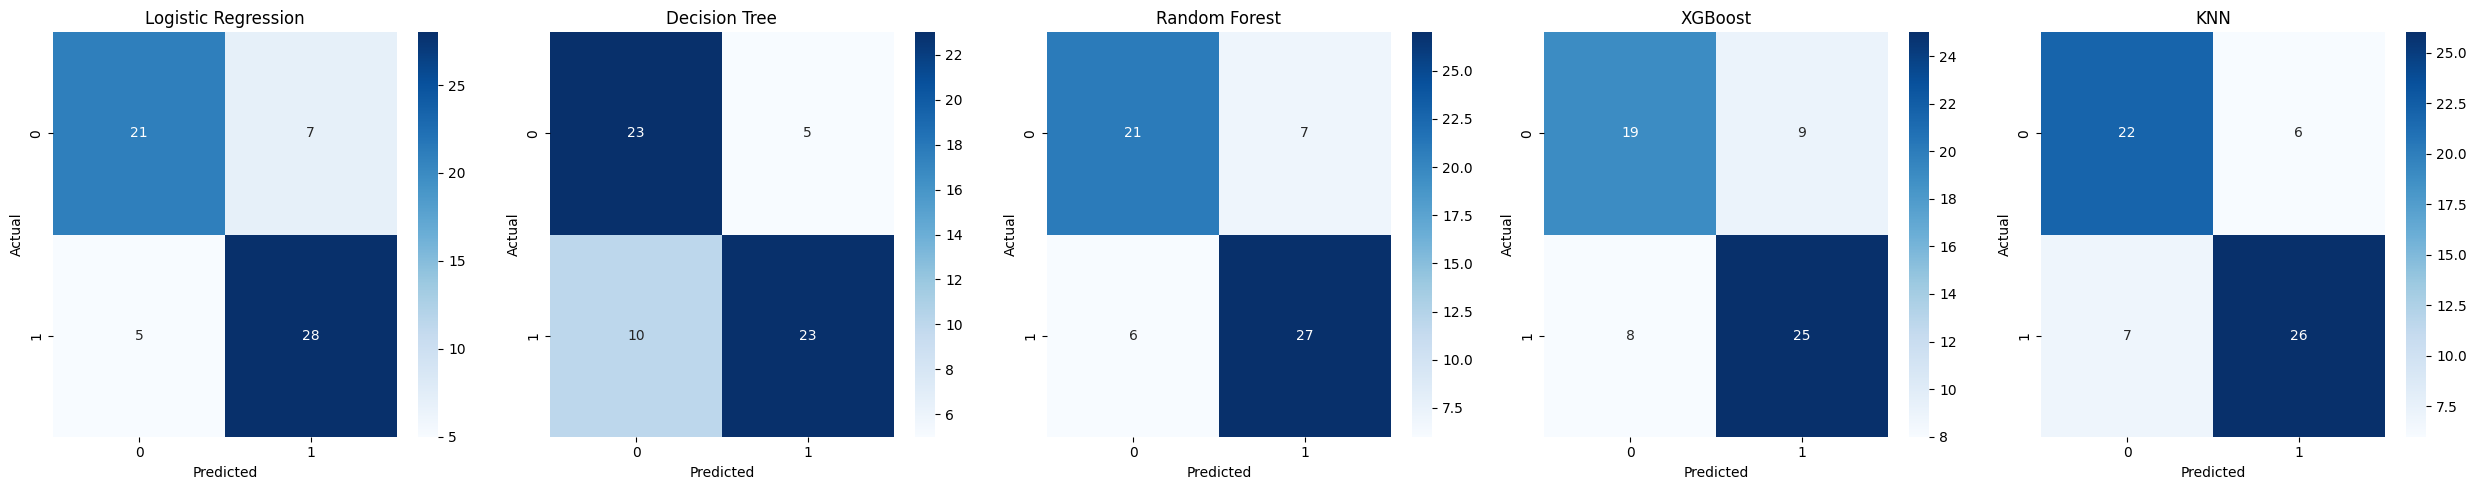

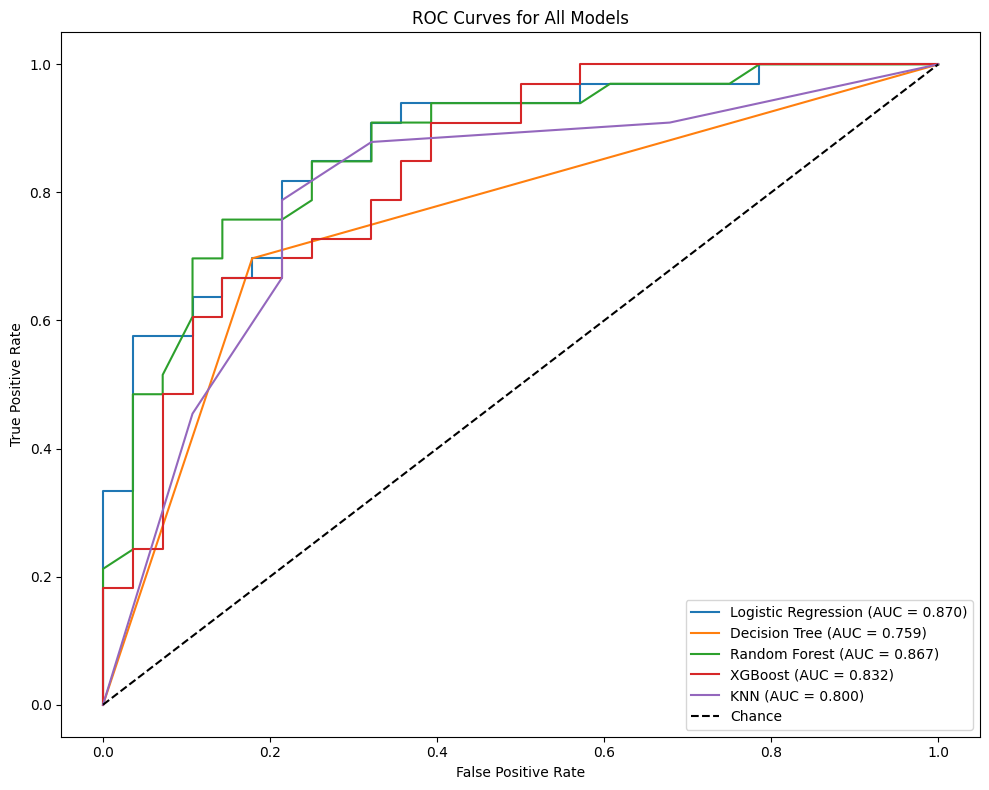

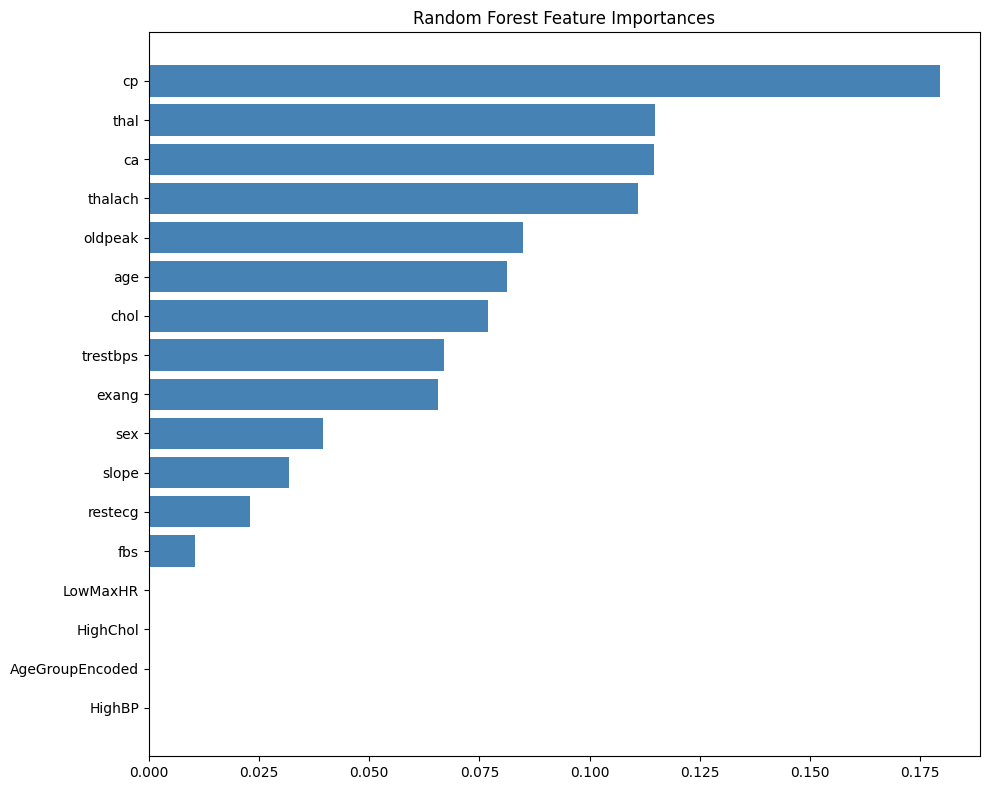

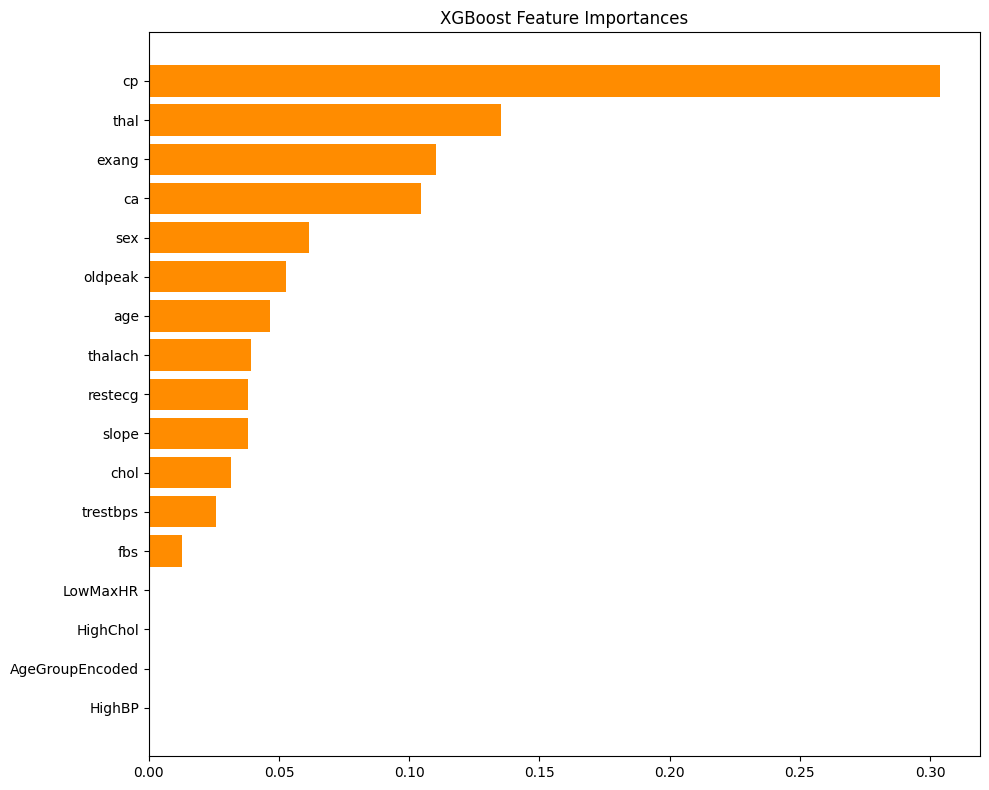

Top 5 features by model:

Logistic Regression:
sex        1.558605
cp         0.937108
exang      0.915517
thalach    0.808823
thal       0.805204
dtype: float64

Decision Tree:
cp         0.331364
ca         0.102412
thal       0.101422
chol       0.089387
oldpeak    0.084120
dtype: float64

Random Forest:
cp         0.179555
thal       0.114734
ca         0.114591
thalach    0.110936
oldpeak    0.084786
dtype: float64

XGBoost:
cp       0.304015
thal     0.135067
exang    0.110176
ca       0.104592
sex      0.061322
dtype: float32

KNN (Permutation Importance):
ca         0.081967
oldpeak    0.072131
exang      0.036066
thalach    0.034426
age        0.032787
dtype: float64


In [23]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# Store predictions and probabilities for all models
model_preds = {}
model_probas = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    model_preds[name] = y_pred
    model_probas[name] = y_score

# Plot confusion matrices
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, y_pred) in zip(axs, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrices.png')
plt.show()

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))
for name, y_score in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {model_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/plots/roc_curves.png')
plt.show()

# Feature importances
feature_names = X.columns.tolist()
rf_importances = models['Random Forest'].feature_importances_
xgb_importances = models['XGBoost'].feature_importances_

rf_df = pd.DataFrame({'feature': feature_names, 'importance': rf_importances})
rf_df = rf_df.sort_values('importance', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(rf_df['feature'], rf_df['importance'], color='steelblue')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/plots/random_forest_feature_importance.png')
plt.show()

xgb_df = pd.DataFrame({'feature': feature_names, 'importance': xgb_importances})
xgb_df = xgb_df.sort_values('importance', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(xgb_df['feature'], xgb_df['importance'], color='darkorange')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/plots/xgboost_feature_importance.png')
plt.show()

# Top 5 most important features by model
print('Top 5 features by model:')

# Logistic Regression coefficients
log_coefs = pd.Series(np.abs(models['Logistic Regression'].coef_[0]), index=feature_names)
print('\nLogistic Regression:')
print(log_coefs.sort_values(ascending=False).head(5))

print('\nDecision Tree:')
print(pd.Series(models['Decision Tree'].feature_importances_, index=feature_names).sort_values(ascending=False).head(5))

print('\nRandom Forest:')
print(pd.Series(rf_importances, index=feature_names).sort_values(ascending=False).head(5))

print('\nXGBoost:')
print(pd.Series(xgb_importances, index=feature_names).sort_values(ascending=False).head(5))

print('\nKNN (Permutation Importance):')
perm = permutation_importance(models['KNN'], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=feature_names)
print(perm_importances.sort_values(ascending=False).head(5))
